# Hand-On yet Mathematically Time Series Forecasting: SARIMAX

We will start by decomposing the meaning of SARIMAX (Seasonal Autoregressive Integrated Moving Averages with eXogenous factors). For that matter, let $X\colon \mathbb Z_{+} \to \mathbb R$ be a time series indexed by discrete non-negative time.

## Autoregressive (AR)

The time series is said to be autoregressive of order $p$ if
$$
    X(t) = e(t) + \sum_{k=1}^{p} a_k X(t-k),
$$
where $e\colon \mathbb Z_{+} \to \mathbb R$ is the error function, usually assume to be a mean zero gaussian with variance $\sigma^2$. If we let $B$ be the left-shift or backward operator, that is, $B X(t) = X(t-1)$, then
$$
    (1 - \sum_{k=1}^{p} a_k B^k) X(t) = e(t).
$$

## Moving Averages (MA)

The time series is said to be on moving averages of order $q$ if
$$
    X(t) = e(t) - \sum_{k=1}^{q} b_k e(t-k).
$$
That is, $X(t)$ can be reconstructed by a series of shocks or jumps. Usually, the $e(t)$'s are assumed independent and normally distributed. In particular, this makes $X$ stationary.

## Mixed models and relationship between AR and MA

Denote by $\alpha(B) = 1 - \sum_{k=1}^{p} a_k B^{k}$ and $\beta(B) = 1 + \sum_{k=1}^q b_k B^k$, so that the AR and the MA model can be writen succintly as:
$$
    \alpha(B) X(t) = e(t) \qquad X(t) = \beta(B) e(t).
$$
Hence, if we assume that $X(t)$ fits both models, we get that $\alpha(B)^{-1} \approx \beta(B)$ and $\beta(B)^{-1} = \alpha(B)$.

**Theorem 1.** For $\alpha(B)$ to is invertible, it is a necessary condition that the zeroes of $\alpha(z)$ lie outside the unit complex disc.
In particular, if $\alpha$ is invertible the AR model is stationary.

<span style="color: blue">

**Proof**
Suppose that $\alpha(z) = (z-z_1)\cdots(z-z_n)$, where the $z_i$ are the zeroes of the polynomial. For $n=1$ we get that
$$
    \alpha(z)^{-1} = (z-z_1)^{-1} = - z^{-1} \sum_{k\ge 0} (z/z_1)^{k}
$$
Since the operator norm of $B$ is one (see **Lemma 1.** below), we need this series to converge for all $|z| < 1$. The last condition fails if $|z_1| < 1$ since $|z/z_1|^k = (|z|/|z_1|)^k$ is greater than $1$ for $1 > |z| > |z_1|$.
Next, suppose $n\ge 2$ and that $|z_1| < 1$. Then,
$$
    \alpha(z)^{-1} = (z-z_1)^{-1} \cdots (z-z_n)^{-1}
$$
and the same argument applies.

</span>

**Lemma 1.** The operator norm of $B$, defined as $|B| = \sup |B(Y)|_{\infty}$ over all functions $Y\colon \mathbb Z_{+} \to \mathbb R$ is one.

<span style="color: blue">

**Proof**
Recall that $|Y|_{\infty} = \sup_{t\in \mathbb Z_{+}} |Y(t)|$. Hence, taking $Y = 1$ for all times gives that $|B| \ge 1$. Clearly $|B| \le 1$, since otherwise there would exists a function $Y$ taking a value greater than $1$ and therefore it cannot appear in the supremum.

</span>

Below there are some plots for a AR, MA and ARMA models of order 2.

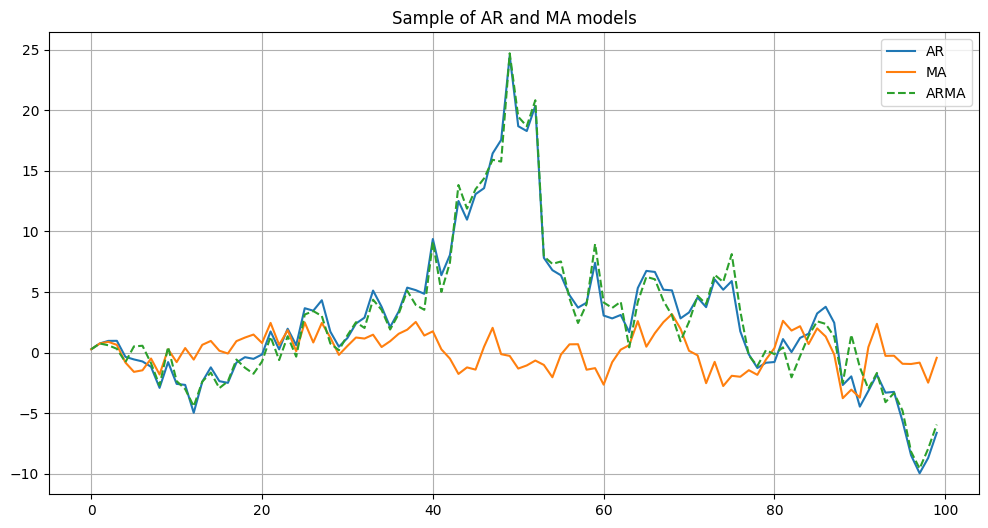

In [29]:
import numpy as np
import matplotlib.pyplot as plt

p, q = 2, 2

#  AR
e = np.random.randn(100)
a = np.random.rand(100)

X_AR = np.zeros(100)
X_AR[0] = 0.5

#  MA
b = np.random.rand(100)
X_MA = np.zeros(100)

#  ARMA
X_ARMA = np.zeros(100)

for i in range(100):
    X_AR[i] = X_AR[i-p:i] @ a[i-p:i] + e[i]
    X_MA[i] = e[i-q:i] @ b[i-q:i] + e[i]
    X_ARMA[i] = e[i] + X_AR[i-p:i] @ a[i-p:i] - e[i-q:i] @ b[i-q:i]

plt.figure(figsize=(12, 6))
plt.title('Sample of AR and MA models')
plt.plot(X_AR, label='AR')
plt.plot(X_MA, label='MA')
plt.plot(X_ARMA, '--', label='ARMA')
plt.legend()
plt.grid(True)
plt.show();

After some trials, we are convinced that MA models are oscillating around zero and AR models peaks a lot following the local trend, and the mixture seems to make small corrections.

For reference, here is the historic close price of a security that we'll be studying (LATAM, a chilean airline). You can see the similarity in shape with the ARMA model and understand that it may be a useful tool in analyzing time series.

[*********************100%***********************]  1 of 1 completed


Ticker         LTM.SN
Date                 
2000-01-03  43.256977
2000-01-10  52.116833
2000-01-17  55.243851
2000-01-24  52.116833
2000-01-31  54.722679

Data shape: (1357, 1)


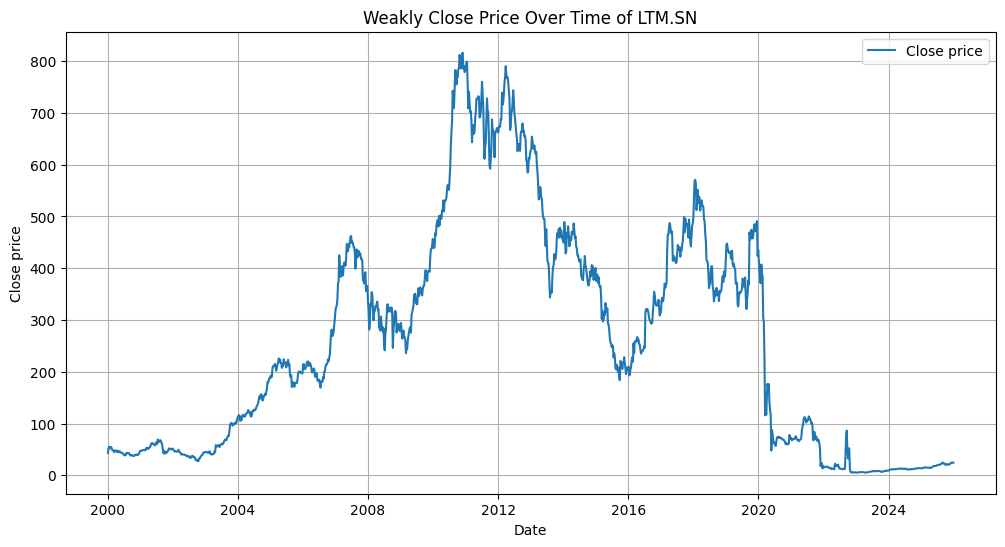

In [30]:
import yfinance as yf

actor = 'LTM.SN'
df = yf.download(actor, start='2000-01-01', end='2025-12-31', interval='1wk')['Close']

print(f"\nData shape: {df.shape}")

plt.figure(figsize=(12, 6))
plt.plot(df.index, df, label='Close price')
plt.title(f'Weakly Close Price Over Time of {actor}')
plt.xlabel('Date')
plt.ylabel('Close price')
plt.legend()
plt.grid(True)
plt.show();

Recall that MA is always stationary. If $\alpha$ fails to be invertible then AR is non-stationary. It is pretty clear that if a zeroes $\alpha$ lies inside the unit circle the process grows uncontrolled (check this!). The next case is that we have a number $d$ of zeroes on the unit circle, in that case, $\alpha(B) = \tilde \alpha(B) (1-B)^{d}$ and we can write the ARMA model as
$$
    \tilde \alpha(B) (1-B)^{d} X(t) = e(t).
$$
Write $\nabla^d = (1 - B)^{d}$ for the $d$-difference operator, acting as
$$
\left\{
\begin{aligned}
    \nabla X(t) &= X(t) - X(t-1) \\
    \nabla^d X(t) &= \sum_{k=1}^{d} \binom{d}{k} (-1)^k X(t-k)
\end{aligned}
\right.
$$
and denoting $W(t) = \nabla^d X(t)$ we can write a stationary process on $W(t)$,
$$
    \tilde\alpha(B) W(t) = e(t).
$$

## Integrated (I)

Since $W(t) = \nabla^d X(t)$, it holds that $\nabla^{-d} W(t) = X(t)$. Notice that
$$
    \nabla^{-1} W(t) = (1-B)^{-1} W(t) = \sum_{k=0}^{\infty} W(t-k),
$$
and
$$
    \nabla^{-2} 
    = \sum_{k\ge 0} (k+1) B^{k}.
$$
Expressions can be obtained for the general case of $\nabla^{-d}$, the point is that all these operators ends up weight-summing values of the time series, and hence, $X(t)$ is constructed by weight-summing the values of a stationary process (recall that $\tilde \alpha(B) W(t) = e(t)$). In the continuous case, the time series would be a weighted integral $X(t) = \int_{s\le t} c(s) W(s) \, ds$, thus "integrated".


## General ARIMA

We have defined the ARMA($p,d,q$) process, where $p$ is the number of steps to look back at $X$, $q$ the number of steps to look back at $e$ and $d$ is the non-stationarity degree. In the general case, the ARIMA model reads
$$
    \tilde \alpha(B) \nabla^d X(t) = b_0 + \beta(B) e(t)
$$
where $\tilde \alpha(B) = 1 - \sum_{k=1}^{p} a_k B^k$ and $\beta(B) = 1 - \sum_{k=1}^{q} b_k B^k$, both invertible with zeroes outside the unit disc. In total, the model has $p+q+2$ parameters accounting for the variance of the error $e$ and the constant $b_0$.

> The constant $b_0$ allows for deterministic linear trends. We take $b_0=0$, expressing no deterministic linear trends. For details see [1] at the end.

# References

* [1] "Time series analysis: Forecasting and control", G. Box \& G. Jenkins \& G. Reinsel \& G. Ljung, Wiley 5th edition.